In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# grads_path = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/block__8_11__3/2025_10_27-18_32_46/diagnostic/grad_2025-10-27_18-32-55.csv"
# dist_path = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/block__8_11__3/2025_10_27-18_32_46/diagnostic/cosine_2025-10-27_18-32-55.csv"

grads_path = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/block__8_11__5/2025_10_29-13_00_36/diagnostic/grad_2025-10-29_13-00-43.csv"
dist_path = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/block__8_11__5/2025_10_29-13_00_36/diagnostic/cosine_2025-10-29_13-00-43.csv"

# grads_path = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/baseline/2025_10_29-13_52_27/diagnostic/grad_2025-10-29_13-52-35.csv"
# dist_path = "/raid/s3/opengptx/behzad_shomali/instruction_tuning/pretrained_llama/baseline/2025_10_29-13_52_27/diagnostic/cosine_2025-10-29_13-52-35.csv"

In [3]:
grads_df = pd.read_csv(grads_path)
dist_df = pd.read_csv(dist_path)

In [4]:
print(grads_df.shape)
grads_df.head(100)

(4650015, 10)


,global_step,step,layer,layer_name,is_recurrent,iteration,norm,mean,max,std
0,0,0,0,NaN,False,0,0.000000,0.000000,0.000000,0.000000
1,20,0,-100,model.norm.weight,False,0,0.018066,0.000103,0.005615,0.000387
2,20,1,12,model.layers.12.mlp.down_proj.weight,False,0,1.039062,0.000000,0.012756,0.000254
3,20,2,12,model.layers.12.mlp.up_proj.weight,False,0,0.660156,-0.000000,0.043213,0.000161
4,20,3,12,model.layers.12.mlp.gate_proj.weight,False,0,0.382812,0.000000,0.017456,0.000093
...,...,...,...,...,...,...,...,...,...,...
95,20,94,8,model.layers.8.layer_block.2.self_attn.k_proj....,False,0,0.172852,-0.000000,0.019409,0.000169
96,20,95,8,model.layers.8.layer_block.2.self_attn.q_proj....,False,0,0.259766,0.000000,0.014893,0.000127
97,20,96,8,model.layers.8.layer_block.2.input_layernorm.w...,False,0,0.015747,-0.000012,0.008728,0.000349
98,20,97,0,3,True,3,0.018311,-0.000000,0.000366,0.000006


In [5]:
print(dist_df.shape)
dist_df.head()

(75000, 6)


,global_step,iteration,mean,min,max,std
0,20,0,0.477404,0.248779,0.999729,0.060342
1,20,1,0.940103,0.831097,0.999736,0.015670
2,20,2,0.981162,0.933254,0.999741,0.005805
3,20,3,0.988496,0.958639,0.999748,0.004298
4,20,4,0.991798,0.961999,0.999755,0.003219


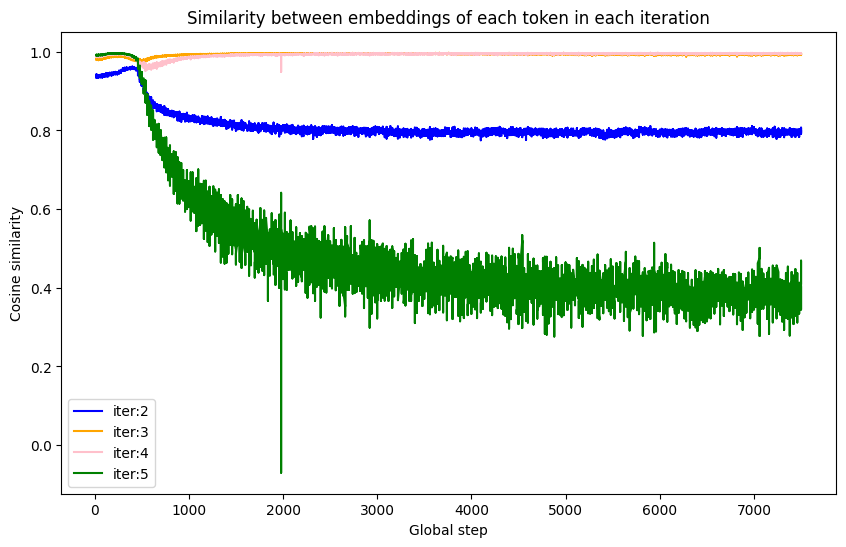

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(10,6))

colors = ["black", "blue", "orange", "pink", "green"]
for iter in dist_df['iteration'].unique():
    if iter == 0:
        continue
    dist_sub_df = dist_df[dist_df["iteration"] == iter]
    ax.plot(dist_sub_df["global_step"], dist_sub_df["mean"], label=f"iter:{iter+1}", color=colors[iter])
    ax.set_xlabel("Global step")
    ax.set_ylabel("Cosine similarity")

plt.title("Similarity between embeddings of each token in each iteration")
plt.legend()

## Grad

In [7]:
def extract_base_layer(name: str) -> str:
    parts = name.split(".")
    # keep up to a consistent depth
    # adjust depending on your structure
    # print(parts)
    if len(parts) >= 5:
        
        if parts[3] == "layer_block":
            return ".".join(parts[:5])
        return ".".join(parts[:3])
    else:
        return name

In [8]:
grads_df["layer_name"] = grads_df["layer_name"].astype(str)
grads_df

,global_step,step,layer,layer_name,is_recurrent,iteration,norm,mean,max,std
0,0,0,0,nan,False,0,0.000000,0.000000,0.000000,0.000000
1,20,0,-100,model.norm.weight,False,0,0.018066,0.000103,0.005615,0.000387
2,20,1,12,model.layers.12.mlp.down_proj.weight,False,0,1.039062,0.000000,0.012756,0.000254
3,20,2,12,model.layers.12.mlp.up_proj.weight,False,0,0.660156,-0.000000,0.043213,0.000161
4,20,3,12,model.layers.12.mlp.gate_proj.weight,False,0,0.382812,0.000000,0.017456,0.000093
...,...,...,...,...,...,...,...,...,...,...
4650010,7500,4649995,0,model.layers.0.self_attn.v_proj.weight,False,0,0.132812,0.000000,0.009216,0.000130
4650011,7500,4649996,0,model.layers.0.self_attn.k_proj.weight,False,0,0.017700,0.000000,0.002411,0.000017
4650012,7500,4649997,0,model.layers.0.self_attn.q_proj.weight,False,0,0.007996,0.000000,0.000259,0.000004
4650013,7500,4649998,0,model.layers.0.input_layernorm.weight,False,0,0.006104,0.000012,0.001259,0.000134


In [9]:
grads_df["base_layer"] = grads_df["layer_name"].apply(extract_base_layer)
grads_df["base_layer"]

0                                nan
1                  model.norm.weight
2                    model.layers.12
3                    model.layers.12
4                    model.layers.12
                     ...            
4650010               model.layers.0
4650011               model.layers.0
4650012               model.layers.0
4650013               model.layers.0
4650014    model.embed_tokens.weight
Name: base_layer, Length: 4650015, dtype: object

In [10]:
grads_df.dropna()

,global_step,step,layer,layer_name,is_recurrent,iteration,norm,mean,max,std,base_layer
0,0,0,0,nan,False,0,0.000000,0.000000,0.000000,0.000000,nan
1,20,0,-100,model.norm.weight,False,0,0.018066,0.000103,0.005615,0.000387,model.norm.weight
2,20,1,12,model.layers.12.mlp.down_proj.weight,False,0,1.039062,0.000000,0.012756,0.000254,model.layers.12
3,20,2,12,model.layers.12.mlp.up_proj.weight,False,0,0.660156,-0.000000,0.043213,0.000161,model.layers.12
4,20,3,12,model.layers.12.mlp.gate_proj.weight,False,0,0.382812,0.000000,0.017456,0.000093,model.layers.12
...,...,...,...,...,...,...,...,...,...,...,...
4650010,7500,4649995,0,model.layers.0.self_attn.v_proj.weight,False,0,0.132812,0.000000,0.009216,0.000130,model.layers.0
4650011,7500,4649996,0,model.layers.0.self_attn.k_proj.weight,False,0,0.017700,0.000000,0.002411,0.000017,model.layers.0
4650012,7500,4649997,0,model.layers.0.self_attn.q_proj.weight,False,0,0.007996,0.000000,0.000259,0.000004,model.layers.0
4650013,7500,4649998,0,model.layers.0.input_layernorm.weight,False,0,0.006104,0.000012,0.001259,0.000134,model.layers.0


/tmp/ipykernel_1099877/1014014255.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["step"] = filtered_df.index


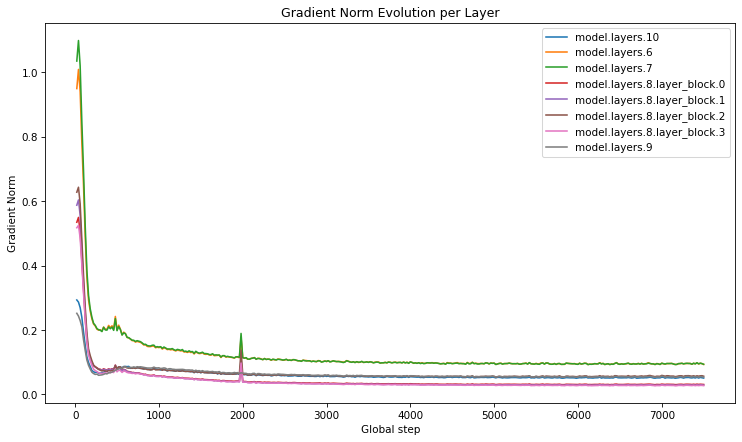

In [11]:
grads_df = grads_df.replace(["NaN", "None", "nan", ""], pd.NA)
filtered_df = grads_df.dropna()

# Optionally remove invalid steps
# df = df[df["step"] != -100].copy()

# If 'step' column is broken, use index instead
filtered_df["step"] = filtered_df.index

# --- Plot gradient norm evolution per layer ---
plt.figure(figsize=(10, 6), dpi=75)

beg_limit = 0
end_limit = 10000
groups_to_show = [
    "model.layers.6",
    "model.layers.7",
    "model.layers.8",
    "model.layers.9",
    "model.layers.10"
]
for layer_name, group in filtered_df.groupby("base_layer"):
    if "weight" in layer_name or not any(g in layer_name for g in groups_to_show):
        continue
    # group = group[group["step"] <= end_limit]
    # group = group[beg_limit <= group["step"]]
    group = group[["step", "norm", "global_step", "base_layer", "iteration"]].groupby(['global_step', 'base_layer']).mean().reset_index()
    plt.plot(group["global_step"], group["norm"], label=f"{layer_name}")

# plt.yscale("log")
plt.xlabel("Global step")
plt.ylabel("Gradient Norm")
plt.title("Gradient Norm Evolution per Layer")
plt.legend()
plt.tight_layout()
plt.show()

In [92]:
end_limit

7982610

In [107]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
import numpy as np

# Data preprocessing
grads_df = grads_df.replace(["NaN", "None", "nan", ""], pd.NA)
filtered_df = grads_df.dropna()
filtered_df["step"] = filtered_df.index

# Configuration
window_size = 4000
beg_limit = 0
end_limit = int(filtered_df["step"].max())
groups_to_show = ["model.layers.8"]

# Filter and prepare data
plot_data = {}
for layer_name, group in filtered_df.groupby("base_layer"):
    if "weight" in layer_name:# or not any(g in layer_name for g in groups_to_show):
        continue
    group = group[group["step"] <= end_limit]
    group = group[beg_limit <= group["step"]]
    if len(group) > 0:
        plot_data[layer_name] = group.sort_values("step")

# Get sorted layer names
layer_names = sorted(plot_data.keys())
n_layers = len(layer_names)

# Determine window positions
min_step = beg_limit
max_step = end_limit
window_starts = range(min_step, max_step - window_size + 1, 2000)  # Step by 2000

# Create figure with subplots (4x4 grid for 16 layers)
n_rows = 4
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16), dpi=75)
axes = axes.flatten()  # Flatten to 1D array for easier indexing

def animate(frame_idx):
    print(f"Index: {frame_idx}/{len(list(window_starts))}", end="\r")
    window_start = list(window_starts)[frame_idx]
    window_end = window_start + window_size
    
    # Clear all axes
    for ax in axes:
        ax.clear()
    
    # Plot each layer in its own subplot
    for idx, layer_name in enumerate(layer_names):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        group = plot_data[layer_name]
        windowed = group[(group["step"] >= window_start) & (group["step"] < window_end)]
        
        if len(windowed) > 0:
            ax.plot(windowed["step"][::8], windowed["norm"][::8], linewidth=1.5, color='C0')
        
        ax.set_yscale("log")
        ax.set_xlabel("Step", fontsize=9)
        ax.set_ylabel("Grad Norm", fontsize=9)
        ax.set_title(f"{layer_name}", fontsize=10, pad=5)
        ax.set_xlim(window_start, window_end)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=8)
    
    # Hide unused subplots
    for idx in range(n_layers, len(axes)):
        axes[idx].axis('off')
    
    # Add overall title
    fig.suptitle(f"Gradient Norm Evolution (Window: {window_start}-{window_end})", 
                 fontsize=16, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.99])

# Create animation
anim = animation.FuncAnimation(fig, animate, frames=len(window_starts), 
                              interval=100, repeat=True)

# Save as GIF
writer = PillowWriter(fps=10)
output_path = "/raid/s3/opengptx/behzad_shomali/modalities/src/modalities/notebooks/figures/Llama_block__8_11__3/gradient_norm_evolution.gif"
anim.save(output_path, writer=writer)
plt.close()

print(f"\nGIF created successfully with {len(window_starts)} frames!")
print(f"Number of layers: {n_layers}")
print(f"Window size: {window_size} steps")
print(f"Range: {min_step} to {max_step}")
print(f"File saved as: {output_path}")

/tmp/ipykernel_432612/1039603091.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["step"] = filtered_df.index


Index: 3989/3990
GIF created successfully with 3990 frames!
Number of layers: 16
Window size: 4000 steps
Range: 0 to 7982839
File saved as: /raid/s3/opengptx/behzad_shomali/modalities/src/modalities/notebooks/figures/Llama_block__8_11__3/gradient_norm_evolution.gif
